<h1 style="font-size:25px; font-weight:700; margin-bottom:10px;">
Comparing Linear and Ensemble Methods for Customer Subscription Prediction
</h1>
<div style="font-size:24px; font-family:'Times New Roman', Times, serif; margin-top:0px;">
<i>An empirical evaluation of logistic regression, random forest, and gradient boosting models</i>
</div>


## Abstract

- Evaluates logistic regression, random forest, and gradient boosting for predicting customer subscription outcomes on a structured marketing dataset
- Assessed via a hold-out train/test split, then more rigorously via Monte Carlo cross-validation (100 replications); measured by misclassification error and AUC
- Hold-out: gradient boosting has the highest test AUC (0.8058); random forest has the lowest test error (0.1041)
- Monte Carlo CV: random forest has the lowest mean test error (0.1054); gradient boosting has the highest mean AUC (0.7990), with small standard deviations across replications indicating stable performance
- `poutcome_success` is a consistently influential predictor across all models; tree-based models weight continuous variables (`balance`, `age`, `day`) more, logistic regression weights campaign-related categorical predictors (`contact_unknown`, `housing`, seasonal `month` indicators) more
- <b><u>Gradient boosting selected as the final model</u></b>: highest average AUC (stronger discrimination across thresholds) plus flexibility for nonlinear relationships


## Introduction

- Goal: predict whether a customer subscribes to a term deposit<span style="color: darkred; font-weight: bold;"><sup>1</sup></span>, using demographic, financial, and prior-contact data from a structured marketing dataset
- Three approaches compared: logistic regression (interpretable baseline), random forest, and gradient boosting (both more flexible, capturing nonlinearity/interactions)
- Evaluated via a hold-out train/test split, then Monte Carlo cross-validation (100 replications), using misclassification error and AUC
- Goal: determine whether flexible ML methods meaningfully improve prediction, and identify the predictors that most influence subscription behavior

---

<div style="margin-left:20px; text-indent:-10px;">
<span style="color: darkred; font-weight: bold;"><sup>1</sup></span> 
    Term deposit is a fixed-term savings product offered by banks.
</div>


### *Initialize Environment*

- NumPy and pandas for data manipulation; matplotlib and seaborn for visualization
- scikit-learn for preprocessing, model training (logistic regression, random forest, gradient boosting), and evaluation (accuracy, confusion matrices, ROC curves)


In [1]:
# Core Libraries
import os
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Scikit-Learn: Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Scikit-Learn: Model Selection
from sklearn.model_selection import train_test_split, GridSearchCV

# Scikit-Learn: Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Scikit-Learn: Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Warnings
import warnings
warnings.filterwarnings('ignore', message = 'A worker stopped while some jobs were given to the executor.*')

# Number of Available Processors
os.cpu_count()


10

### *Utility Functions*

- Helper functions standardize table formatting and evaluation output for consistent reporting across models
- Includes a row-highlighting function for tables and a custom confusion matrix display function


In [2]:
# Row Highlight
def highlight_rows(target_rows):
    if not isinstance(target_rows, (list, tuple, set)):
        target_rows = [target_rows]
        
    def _highlight(row):
        return [
            'background-color: #fff3cd; font-weight: bold'
            if row.name in target_rows else ''
            for _ in row
        ]
    return _highlight

# Confusion Matrix
def display_confusion_matrix(cm, title):

    display(HTML(f"""
    <br>
    <b>{title}</b>
    <table style='border-collapse: collapse; font-size:14px'>
        <tr>
            <th></th>
            <th>Predicted 0</th>
            <th>Predicted 1</th>
        </tr>
        <tr>
            <th>Actual 0</th>
            <td style='padding:6px;border:1px solid #ccc'>{cm[0,0]}</td>
            <td style='padding:6px;border:1px solid #ccc'>{cm[0,1]}</td>
        </tr>
        <tr>
            <th>Actual 1</th>
            <td style='padding:6px;border:1px solid #ccc'>{cm[1,0]}</td>
            <td style='padding:6px;border:1px solid #ccc'>{cm[1,1]}</td>
        </tr>
    </table>
    """))


### Bank Marketing Dataset

- Bank Marketing dataset, UCI Machine Learning Repository<span style="color: darkred; font-weight: bold;"><sup>2</sup></span>: direct phone marketing campaigns by a Portuguese bank offering a term deposit
- 45,211 observations, 16 variables: demographics, financial info, prior marketing interactions
- Target `y`: binary, whether the customer subscribed ("yes"/"no")

---

<div style="margin-left:20px; text-indent:-10px;">
<span style="color: darkred; font-weight: bold;"><sup>2</sup></span> 
    Moro, S., Rita, P., & Cortez, P. (2014). Bank Marketing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306.
</div>


In [3]:
# Load Data & Response Variable Construction
df = pd.read_csv('data/bank-full.csv', sep = ';')

display(HTML(f"""</br>
    Initial Dataset Shape: 
    <span style='background-color: #fff3b0; font-weight: bold; padding: 2px 4px;'>
         {df.shape}
    </span>
"""))

display(df.head(5))


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Data Preprocessing

- Verified data quality and confirmed no missing values
- Removed variables that would introduce information leakage
- Converted categorical variables to a numerical format for classification models
- Ensures the dataset reflects only information available at the time of the marketing decision


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Missing Data Analysis.
</span>

- No missing observations across any variable
- Some categorical variables include an "unknown" category: a valid response, not missing data


In [4]:
# Missing Data Analysis
missing_summary = df.isnull().sum().to_frame('missing_count')
missing_summary['missing_percent'] = (
    missing_summary['missing_count'] / len(df) * 100
)

display(missing_summary.head(5))


,missing_count,missing_percent
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Removal of Post-Outcome Variable.
</span>

- `duration` (length of the last contact call) excluded: it's only recorded after the call, so it isn't available at decision time
- Including it would leak the outcome and produce unrealistically optimistic performance


In [5]:
# Variable Selection/Removal
df = df.drop(columns = ['duration'])


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Class Balance Assessment.
</span>

- Target `y`: ~88.3% did not subscribe, ~11.7% subscribed
- Typical imbalance for marketing response data


In [6]:
# Class Balance Assessment
class_counts = df['y'].value_counts(normalize = True)

display(HTML(f"""</br>
    <b>Class Proportion</b></br>
    
    y = no: 
    <span style='background-color: #fff3b0; font-weight: bold; padding: 2px 4px;'>
         {class_counts.iloc[0]:.4f}
    </span></br>

    y = yes: 
    <span style='background-color: #fff3b0; font-weight: bold; padding: 2px 4px;'>
         {class_counts.iloc[1]:.4f}
    </span>
"""))


## Exploratory Data Analysis (EDA)

- Examines variable distributions, patterns, and relationships with the target before modeling
- Focuses on summary statistics, class balance, and visualizations of demographic, financial, and campaign variables


### Data Structure & Summary Statistics

- 6 numeric variables, 9 categorical variables, no missing observations (**Table 1**)
- `age`: 18–95 years, mean ≈ 40.9
- `balance`: wide range (−8,019 to over 102,000 euros), highly variable
- `campaign`, `pdays`<span style="color: darkred; font-weight: bold;"><sup>3</sup></span>, `previous`: strongly concentrated at low values, most customers contacted only a few times
- `day`: spans the full 1–31 range

---

<div style="margin-left:20px; text-indent:-10px;">
<span style="color: darkred; font-weight: bold;"><sup>3</sup></span> 
    The variable pdays, which measures the number of days since a customer was last contacted in a previous campaign, takes the value −1 for customers who had not been previously contacted, resulting in a large concentration of observations at −1.
</div>


In [7]:
# Data Structure & Summary Statistics
numeric_vars = df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
categorical_vars = df.select_dtypes(include = ['object', 'category']).columns.tolist()

numeric_vars = [v for v in numeric_vars if v != 'y']
categorical_vars = [v for v in categorical_vars if v != 'y']

display(HTML(f"""
    <b>Variable Summary</b><br>
    
    Numeric Predictors:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {len(numeric_vars)}
    </span><br>
    
    Categorical Predictors:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {len(categorical_vars)}
    </span>
"""))

numeric_summary = (
    df[numeric_vars]
    .describe()
    .T
    .assign(
        missing_pct = df[numeric_vars]
        .isna()
        .mean()
        .mul(100)
    )
    .reset_index()
    .rename(columns = {'index': 'Variable'})
)

display(HTML('<br><b>Table 1: Summary Statistics for Numeric Variables</b>'))
display(
    numeric_summary
        .style
        .hide(axis = 'index')
        .format({
            'count': '{:,.0f}',
            'mean': '{:,.2f}',
            'std': '{:,.2f}',
            'min': '{:,.0f}',
            '25%': '{:.2f}',
            '50%': '{:.2f}',
            '75%': '{:.2f}',
            'max': '{:,.0f}',
            'missing_pct': '{:.2f}'
        })
        .set_properties(subset = ['Variable'], **{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'th.col_heading.level0.col0',
             'props': [('text-align', 'left')]}
        ])
)


Variable,count,mean,std,min,25%,50%,75%,max,missing_pct
age,"45,211",40.94,10.62,18,33.00,39.00,48.00,95,0.00
balance,"45,211","1,362.27","3,044.77","-8,019",72.00,448.00,1428.00,"102,127",0.00
day,"45,211",15.81,8.32,1,8.00,16.00,21.00,31,0.00
campaign,"45,211",2.76,3.10,1,1.00,2.00,3.00,63,0.00
pdays,"45,211",40.20,100.13,-1,-1.00,-1.00,-1.00,871,0.00
previous,"45,211",0.58,2.30,0,0.00,0.00,0.00,275,0.00


- **Table 2**: 9 categorical variables covering demographics (`job`, `marital`, `education`) and financial indicators (`default`, `housing`, `loan`), plus campaign attributes (`contact`, `month`, `poutcome`)
- Category counts range from 2 (binary indicators) to 12 (`job`, `month`)


In [8]:
# Categorical Summary Table
categorical_summary = (
    pd.DataFrame({
        'Variable': categorical_vars,
        'Num Categories': [df[var].nunique() for var in categorical_vars],
        'Missing (%)': [df[var].isna().mean() * 100 for var in categorical_vars]
    })
)

display(HTML('<br><b>Table 2: Summary Statistics for Categorical Variables</b>'))
display(
    categorical_summary
        .style
        .hide(axis = 'index')
        .format({
            'Num Categories': '{:,.0f}',
            'Missing (%)': '{:.2f}'
        })
        .set_properties(subset = ['Variable'], **{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'th.col_heading.level0.col0',
             'props': [('text-align', 'left')]}
        ])
)


Variable,Num Categories,Missing (%)
job,12,0.00
marital,3,0.00
education,4,0.00
default,2,0.00
housing,2,0.00
loan,2,0.00
contact,3,0.00
month,12,0.00
poutcome,4,0.00


### Numeric Variable Analysis

- `campaign` and `previous`: right-skewed, concentrated at small values, most customers contacted only a few times
- `pdays`: substantial dispersion with a large mass at −1


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Numeric Variable Distributions.
</span>

- `age`: moderate dispersion, centered on middle-aged customers, mild right tail (**Figure 1**)
- `balance`: strongly right-skewed, most customers hold modest balances, a few extend very high
- `campaign`, `previous`: heavily concentrated at small counts
- `pdays`: strong concentration at low values with a long right tail
- `day`: spans the full 1–31 range


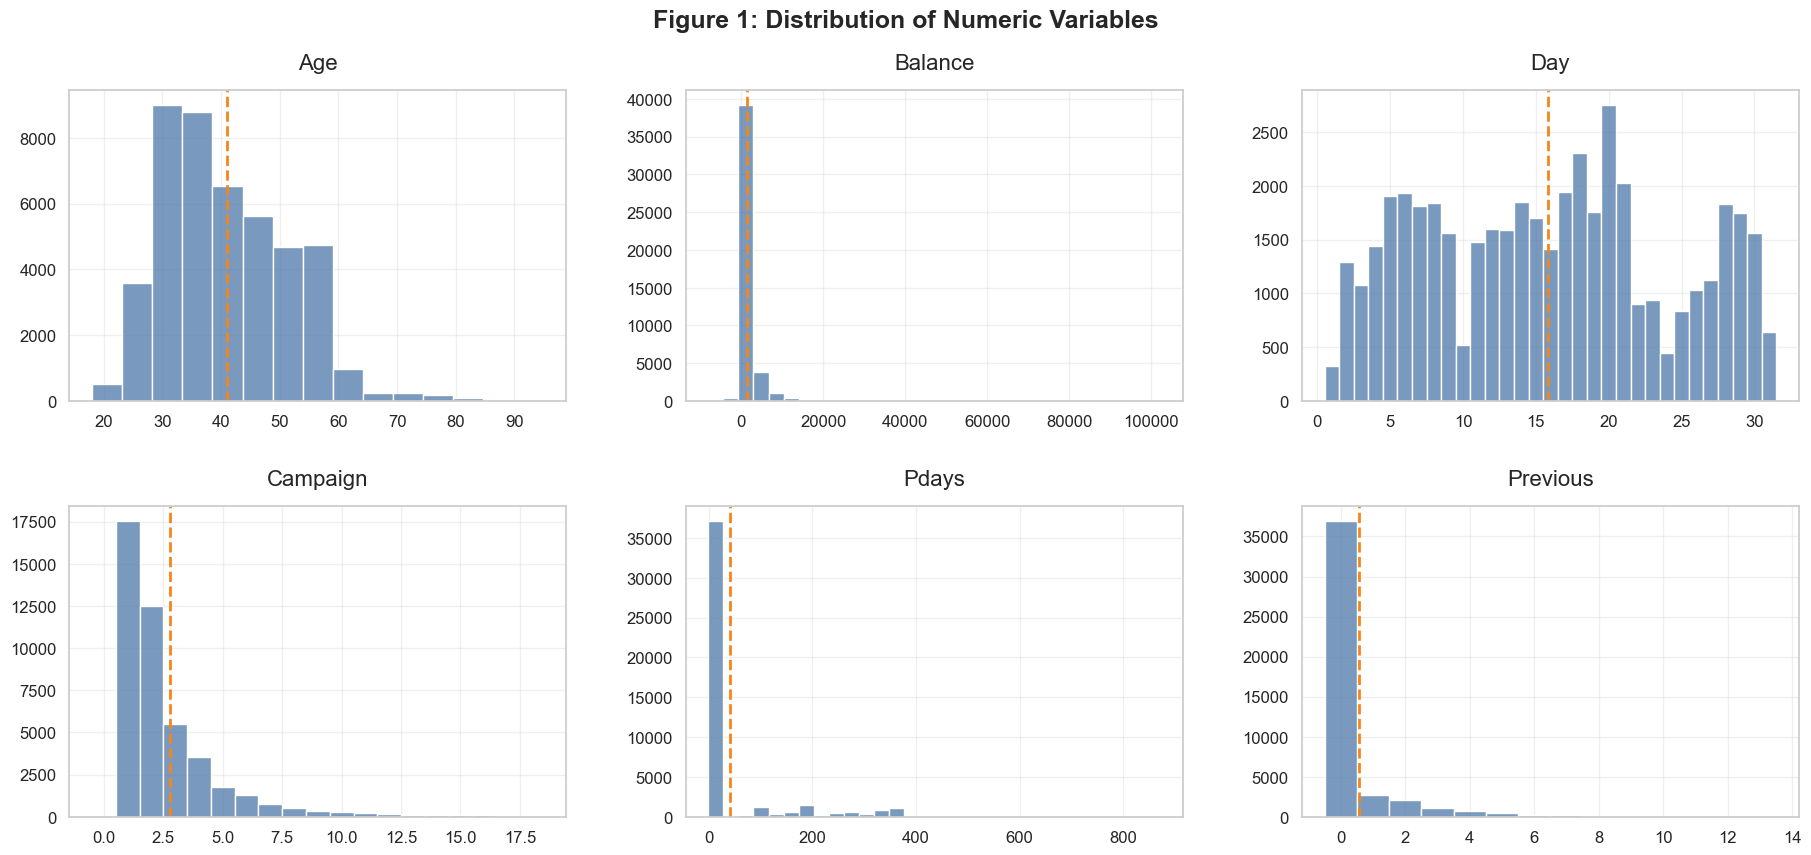

In [9]:
# Numeric Variable Distributions
numeric_features = [
    'age', 'balance', 'day', 'campaign', 'pdays', 'previous'
]

custom_bins = {
    'age': 15,
    'balance': 30,
    'day': np.arange(1, 33) - 0.5,
    'campaign': np.arange(0, 20) - 0.5,
    'pdays': 30,
    'previous': np.arange(0, 15) - 0.5
}

sns.set_theme(style = 'whitegrid')

n_cols = 3
n_rows = int(np.ceil(len(numeric_features) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize = (6*n_cols, 4*n_rows),
    constrained_layout = True
)

fig.set_constrained_layout_pads(
    hspace = 0.10,
    wspace = 0.10
)

axes = axes.flatten()

for i, var in enumerate(numeric_features):

    sns.histplot(
        df[var],
        bins = custom_bins[var],
        color = '#4C78A8',
        edgecolor = 'white',
        linewidth = 1,
        ax=axes[i]
    )

    mean_val = df[var].mean()
    axes[i].axvline(
        mean_val,
        color = '#F58518',
        linestyle = '--',
        linewidth = 2
    )

    axes[i].set_title(var.replace('_', ' ').title(), fontsize = 16, pad = 15)
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis = 'both', labelsize = 12)
    axes[i].grid(True, alpha = 0.3)

for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Figure 1: Distribution of Numeric Variables',
    fontsize = 18,
    fontweight = 'bold',
    y = 1.05
)

plt.show()


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Numeric Variable Distributions by Term Deposit Subscription.
</span>

- **Figure 2**: subscribers tend toward slightly higher balances, though highly right-skewed with outliers
- `campaign` tends to be lower among subscribers, success often comes after few contacts
- `previous` slightly higher among subscribers; `pdays` shows substantial dispersion, with more recent prior contact associated with success
- `day` distributions are similar across both groups: timing within the month isn't strongly related to subscription


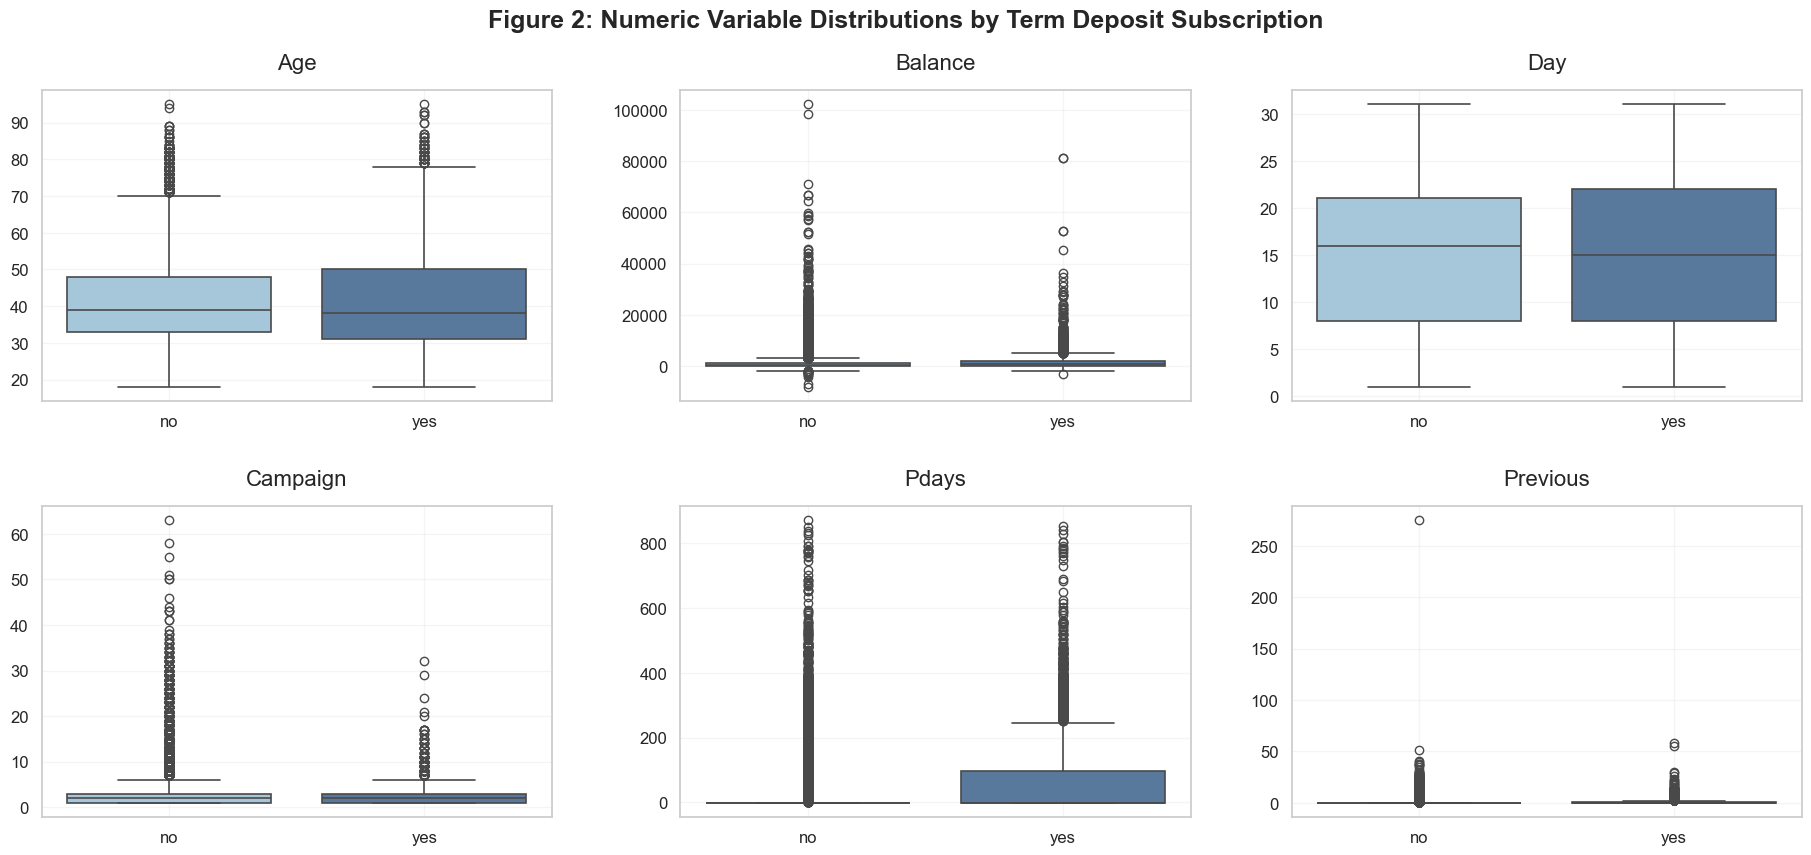

In [10]:
# Boxplots: Numeric Variables vs Target (Term Deposit Subscription)
numeric_features = [
    'age', 'balance', 'day', 'campaign', 'pdays', 'previous'
]

sns.set_theme(style = 'whitegrid')

n_cols = 3
n_rows = int(np.ceil(len(numeric_features) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize = (6*n_cols, 4*n_rows),
    constrained_layout = True
)

fig.set_constrained_layout_pads(
    hspace = 0.10,
    wspace = 0.10
)

axes = axes.flatten()

for i, var in enumerate(numeric_features):

    sns.boxplot(
        x = 'y',
        y = var,
        hue = 'y',
        data = df,
        palette = ['#9ecae1','#4C78A8'],
        linewidth = 1.2,
        ax = axes[i],
        legend = False
    )

    axes[i].set_title(
        var.replace('_', ' ').title(),
        fontsize = 16,
        pad = 15
    )

    axes[i].set_ylabel('')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis = 'both', labelsize = 12)

    axes[i].set_axisbelow(True)
    axes[i].grid(True, alpha = 0.2)

for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Figure 2: Numeric Variable Distributions by Term Deposit Subscription',
    fontsize = 18,
    fontweight = 'bold',
    y = 1.05
)

plt.show()


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Correlation Analysis.
</span>

- Correlation matrix across `age`, `balance`, `day`, `campaign`, `pdays`, `previous`, and `subscription` (**Figure 3**)
- Pairwise correlations are generally weak: limited multicollinearity, variables capture largely distinct information
- Strongest relationship: `pdays` and `previous` (0.45); `day`/`campaign` (0.16) and `age`/`balance` (0.10) are smaller
- Correlations with subscription outcome are weak overall, largest for `pdays` (0.10) and `previous` (0.09)


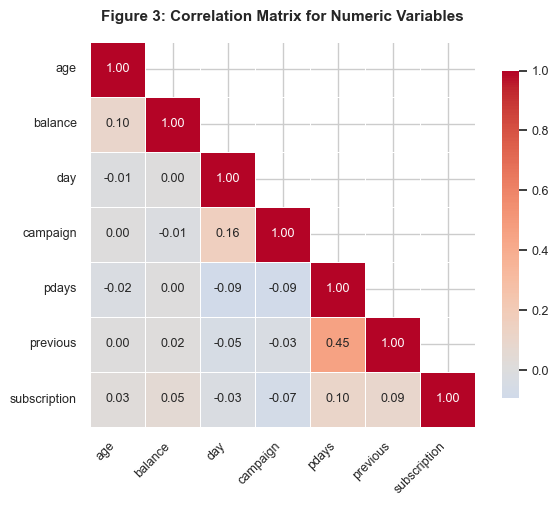

In [11]:
# Correlation Analysis
numeric_vars = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

sns.set_theme(style = 'whitegrid')

corr_df = df[numeric_vars].copy()
corr_df['subscription'] = (df['y'] == 'yes').astype(int)

corr_matrix = corr_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype = bool), k = 1)

plt.figure(figsize = (7, 5))

ax = sns.heatmap(
    corr_matrix,
    mask = mask,
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm',
    center = 0,
    square = True,
    linewidths = 0.5,
    annot_kws = {'size': 9},
    cbar_kws = {'shrink': 0.85}
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize = 9)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation = 45,
    ha = 'right',
    fontsize = 9
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation = 0,
    fontsize = 9
)

ax.set_axisbelow(True)

plt.title(
    'Figure 3: Correlation Matrix for Numeric Variables',
    fontsize = 11,
    fontweight = 'bold',
    pad = 15
)

plt.show()


### Categorical Variable Analysis

- 9 categorical variables covering demographics, financial characteristics, and campaign attributes (**Table 2**)
- Range from binary indicators (`default`, `housing`) to multi-category variables (`job`, `month`)


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Categorical Variable Distributions.
</span>

- `job`: 12 groups, dominated by blue-collar, management, and technician; student and unknown are rare (**Figure 4**)
- `marital`: mostly married; `education`: concentrated in secondary
- `default`: overwhelmingly "no"; housing loans common, personal loans less so
- Most contacts via cellular; campaign activity concentrated in late spring/summer, especially May
- `poutcome`: heavily dominated by "unknown", most customers had no recorded prior outcome


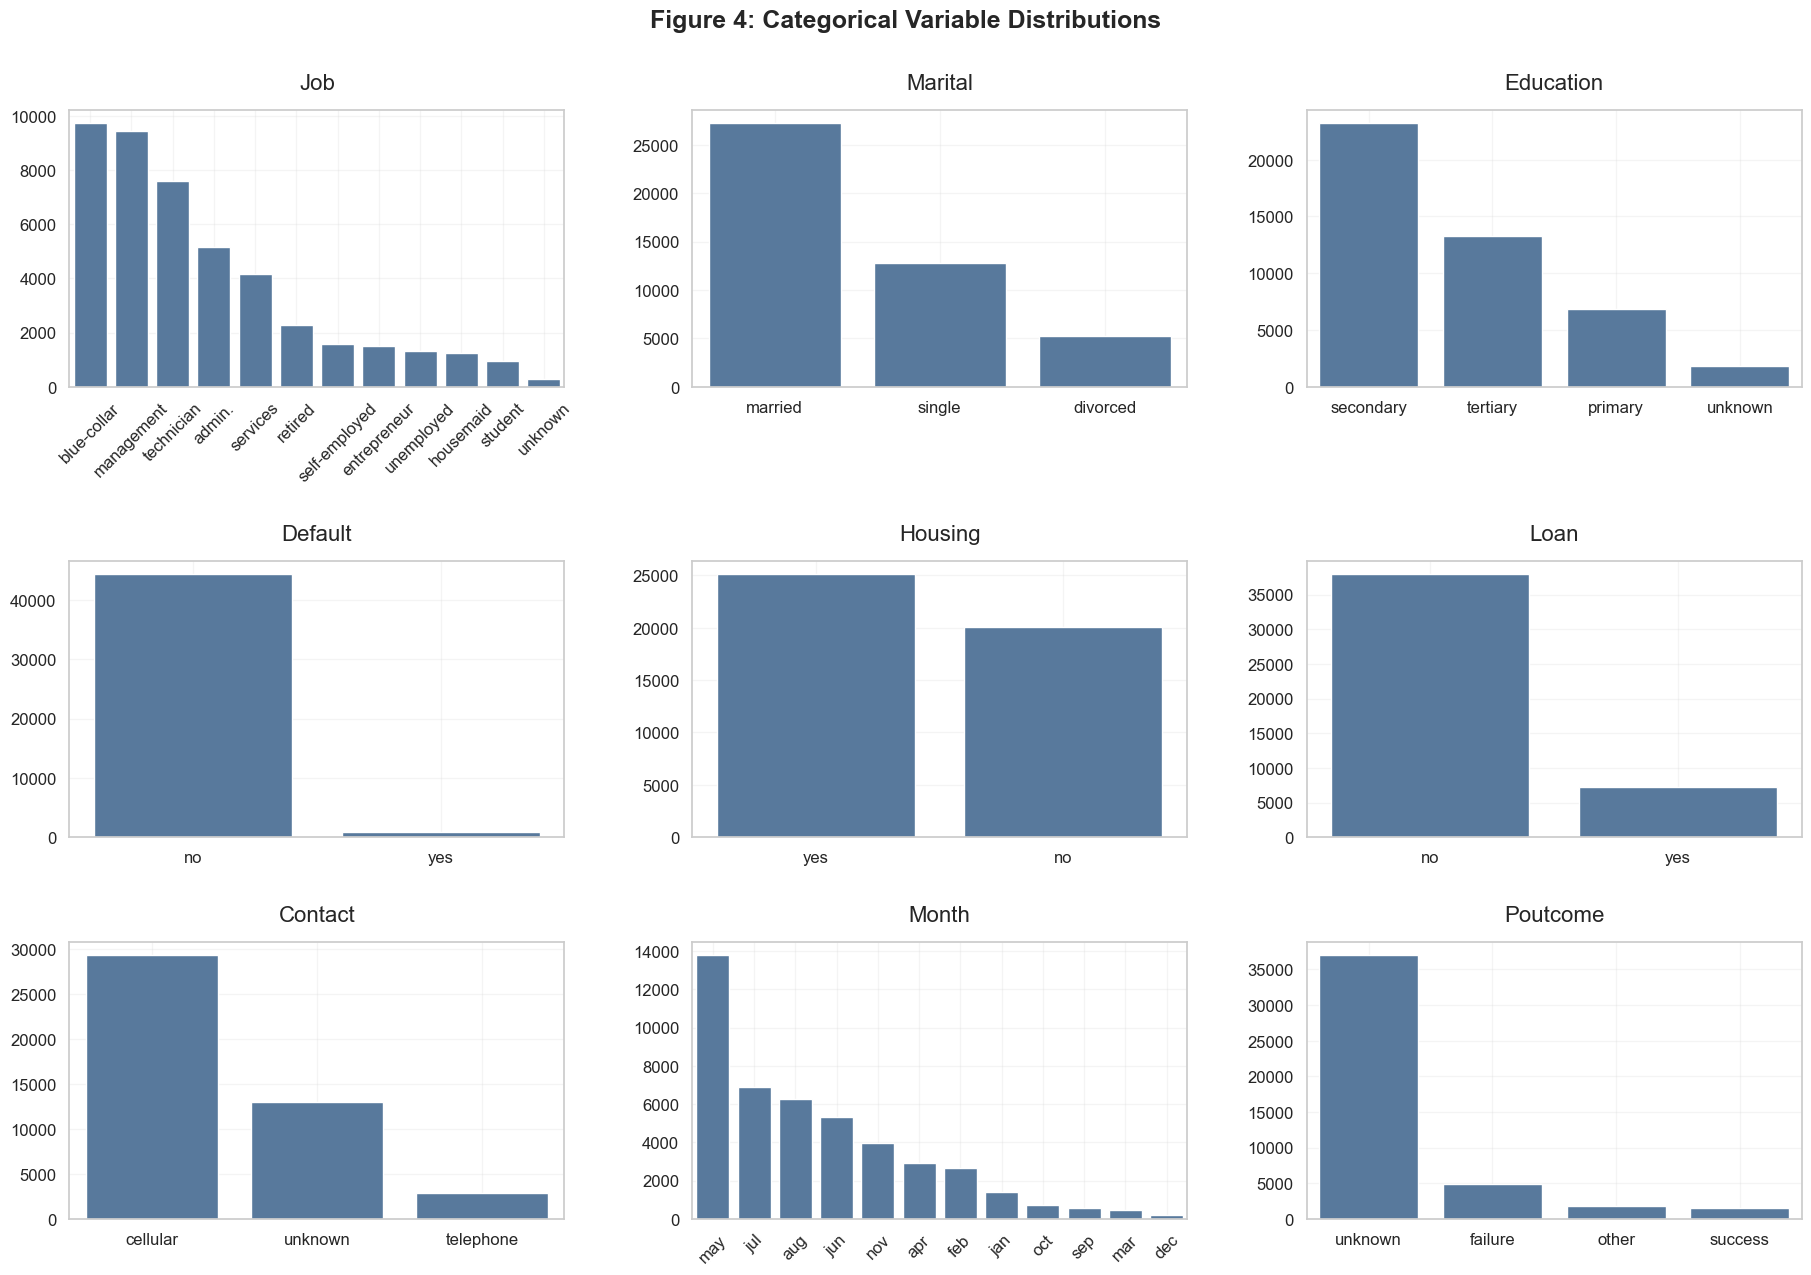

In [12]:
# Overall Categorical Variable Distributions
categorical_features = [
    'job', 'marital', 'education', 'default', 'housing',
    'loan', 'contact', 'month', 'poutcome'
]

sns.set_theme(style = 'whitegrid')

n_cols = 3
n_rows = int(np.ceil(len(categorical_features) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize = (6*n_cols, 4*n_rows),
    constrained_layout = True
)

fig.set_constrained_layout_pads(
    hspace = 0.10,
    wspace = 0.10
)

axes = axes.flatten()

for i, var in enumerate(categorical_features):

    sns.countplot(
        x = df[var],
        ax = axes[i],
        order = df[var].value_counts().index,
        color = '#4C78A8',
        edgecolor = 'white',
        linewidth = 1
    )

    axes[i].set_title(
        var.replace('_', ' ').title(),
        fontsize = 16,
        pad = 15
    )

    axes[i].set_ylabel('')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis = 'both', labelsize = 12)

    if df[var].nunique() > 4:
        axes[i].tick_params(axis = 'x', rotation = 45)

    axes[i].set_axisbelow(True)
    axes[i].grid(True, alpha = 0.2)

for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Figure 4: Categorical Variable Distributions',
    fontsize = 18,
    fontweight = 'bold',
    y = 1.05
)

plt.show()


- Notable class imbalance in `default`, `contact`, and `poutcome`; more diverse category frequencies in `job`, `education`, and `month`


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Categorical Variable Distributions by Term Deposit Subscription.
</span>

- **Figure 5**: `poutcome` shows the strongest association, prior "success" customers subscribe at ≈65%, far above failure/other/unknown
- `contact`: higher subscription rates for cellular contacts
- `education`, `job`: smaller differences; students and retirees somewhat higher
- `month`: visible temporal variation, suggesting seasonality
- `marital`, `default`, `housing`, `loan`: relatively small differences across categories


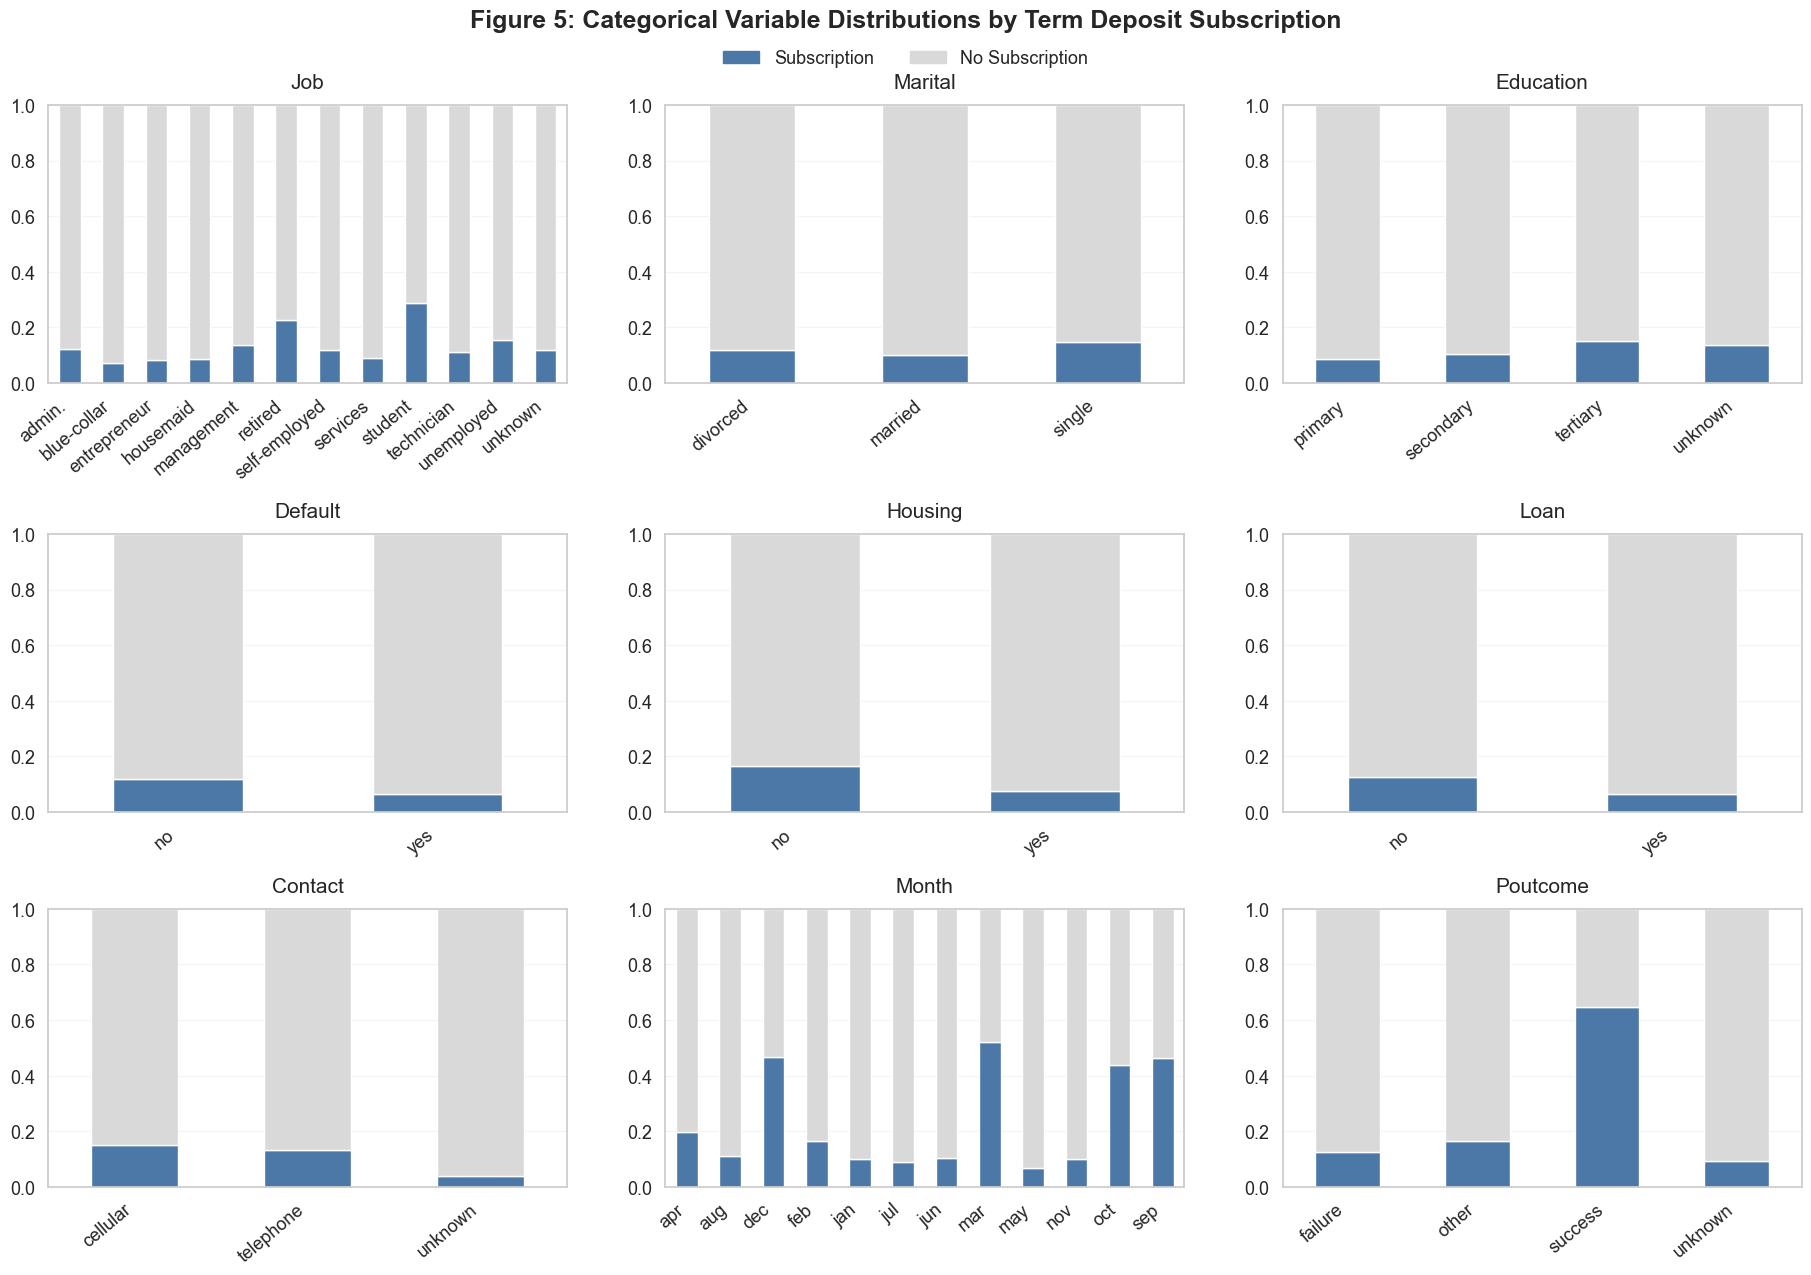

In [13]:
# Row-Normalized Crosstabs for All Categorical Predictors
sns.set_theme(style = 'whitegrid')

categorical_features = [
    'job', 'marital', 'education', 'default', 'housing',
    'loan', 'contact', 'month', 'poutcome'
]

n_cols = 3
n_rows = int(np.ceil(len(categorical_features) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize = (6*n_cols, 4*n_rows),
    constrained_layout = True
)

fig.set_constrained_layout_pads(
    hspace = 0.05,
    wspace = 0.10
)

axes = axes.flatten()

for i, var in enumerate(categorical_features):

    ct = pd.crosstab(df[var], df['y'], normalize = 'index')
    ct = ct[['yes', 'no']]

    ct.plot(
        kind = 'bar',
        stacked = True,
        ax = axes[i],
        color = ['#4C78A8', '#D9D9D9'],  # yes = blue | no = grey
        edgecolor = 'white',
        linewidth = 1
    )

    axes[i].set_title(
        var.replace('_', ' ').title(),
        fontsize = 15,
        pad = 12
    )

    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].set_ylim(0, 1)
    
    axes[i].tick_params(axis = 'y', labelsize = 13)
    axes[i].set_xticklabels(
        axes[i].get_xticklabels(),
        rotation = 40,
        ha = 'right',
        fontsize = 13,
        fontweight = 'normal'
    )  
    
    axes[i].set_axisbelow(True)
    axes[i].grid(True, alpha = 0.2)
    axes[i].legend_.remove()

for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

fig.legend(
    handles = [
        plt.Rectangle((0, 0), 1, 1, color = '#4C78A8'),
        plt.Rectangle((0, 0), 1, 1, color = '#D9D9D9')
    ],
    labels = ['Subscription', 'No Subscription'],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.03),
    ncol = 2,
    frameon = False,
    fontsize = 13
)

fig.suptitle(
    'Figure 5: Categorical Variable Distributions by Term Deposit Subscription',
    fontsize = 18,
    fontweight = 'bold',
    y = 1.05
)

plt.show()


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Categorical Variable Encoding.
</span>

- Binary variables (`default`, `housing`, `loan`, target `y`): encoded 1 = "yes", 0 = "no"
- Multi-category variables (`job`, `marital`, `education`, `contact`, `month`, `poutcome`): one-hot encoded, one category dropped per variable to avoid perfect multicollinearity
- See **Table 3** for the resulting indicator variables


In [14]:
# Categorical Variable Encoding
df_model = df.copy()

# Binary Categorical Variables
binary_vars = ['default', 'housing', 'loan', 'y']

for col in binary_vars:
    df_model[col] = df_model[col].map({'yes': 1, 'no': 0})

# One-Hot Encoding
categorical_vars = [
    'job',
    'marital',
    'education',
    'contact',
    'month',
    'poutcome'
]

df_model = pd.get_dummies(
    df_model,
    columns = categorical_vars,
    drop_first = True
)

display(HTML(f"""<br>
    Final Dataset Shape:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {df_model.shape}
    </span>
"""))

def get_encoded(prefix):
    return ', '.join(sorted([c for c in df_model.columns if c.startswith(prefix)]))

# Encoding summary table
encoding_summary = pd.DataFrame({
    'Variable': [
        'default',
        'housing',
        'loan',
        'y',
        'job',
        'marital',
        'education',
        'contact',
        'month',
        'poutcome'
    ],
    'Encoding': [
        '0 = no, 1 = yes',
        '0 = no, 1 = yes',
        '0 = no, 1 = yes',
        '0 = no, 1 = yes',
        get_encoded('job_'),
        get_encoded('marital_'),
        get_encoded('education_'),
        get_encoded('contact_'),
        get_encoded('month_'),
        get_encoded('poutcome_')
    ]
})

display(HTML('<br><b>Table 3: Encoded Categorical Variables</b>'))

display(
    encoding_summary
        .style
        .hide(axis = 'index')
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'left')]}
        ])
)


Variable,Encoding
default,"0 = no, 1 = yes"
housing,"0 = no, 1 = yes"
loan,"0 = no, 1 = yes"
y,"0 = no, 1 = yes"
job,"job_blue-collar, job_entrepreneur, job_housemaid, job_management, job_retired, job_self-employed, job_services, job_student, job_technician, job_unemployed, job_unknown"
marital,"marital_married, marital_single"
education,"education_secondary, education_tertiary, education_unknown"
contact,"contact_telephone, contact_unknown"
month,"month_aug, month_dec, month_feb, month_jan, month_jul, month_jun, month_mar, month_may, month_nov, month_oct, month_sep"
poutcome,"poutcome_other, poutcome_success, poutcome_unknown"


## Methods: Classification Models

- **Logistic regression**: interpretable baseline classifier
- **Random forest** and **gradient boosting**: ensemble methods evaluated for potential gains in predictive accuracy
  - Random forest: bootstrap samples, random predictor subsets per split
  - Boosting: sequential shallow trees, each correcting prior errors
- Tuning parameters selected via cross-validation on the training data only; models compared by misclassification error on a held-out test set


### Training/Test Split

- Stratified 70/30 train/test split, preserving the target's class distribution
- Training: 31,647 observations; Test: 13,564 observations; 41 predictors after preprocessing
- Class balance nearly identical across both sets (~88.3% / ~11.7%)
- Training set used for estimation and tuning; test set reserved solely for evaluation


In [15]:
# Training/Test Split
X = df_model.drop(columns = ['y'])
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 7, stratify = y)

summary_df = pd.DataFrame({
    'dataset': ['training', 'test'],
    'observations': [X_train.shape[0], X_test.shape[0]],
    'features': [X_train.shape[1], X_test.shape[1]],
    'prop_y0': [
        (y_train == 0).mean(),
        (y_test == 0).mean()
    ],
    'prop_y1': [
        (y_train == 1).mean(),
        (y_test == 1).mean()
    ]
})

display(summary_df)


,dataset,observations,features,prop_y0,prop_y1
0,training,31647,41,0.883022,0.116978
1,test,13564,41,0.882999,0.117001


### Feature Standardization

- Numeric predictors standardized to zero mean, unit variance
- Scaling parameters estimated on the training set only, then applied to the test set: avoids test-set leakage into training


In [16]:
# Predictor Standardization
y_binary = (df['y'] == 'yes').astype(int)
X_raw = df.drop(columns = ['y'])
y_raw = y_binary

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Baseline: Logistic Regression Model

- Models the log-odds of subscription as a linear combination of predictors
- Interpretable benchmark against which the ensemble methods are compared


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Hyperparameter Selection.
</span>

- Grid search, 7-fold cross-validation on training data
- Regularization parameter C ($\ell_2$ penalty) searched over {0.01, 0.1, 1, 10, 100}
- $\ell_2$ chosen for coefficient shrinkage without eliminating predictors, stabilizing estimates under multicollinearity
- Selected by average cross-validated AUC
- Optimal: C = 0.01 (relatively strong regularization)


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Model Performance.
</span>

- Training: accuracy 0.8918 (error 0.1082), AUC 0.7656
- Test: accuracy 0.8931 (error 0.1069), AUC 0.7733
- Similar train/test performance: good generalization, no substantial overfitting
- Correctly classifies most non-subscription outcomes; relatively many false negatives, reflecting class imbalance


In [17]:
# Baseline: Logistic Regression Model
param_grid = {
    'C':[0.01, 0.1, 1, 10, 100]
}

logit = LogisticRegression(solver = 'lbfgs', max_iter = 5000)

# Grid Search w/7-Fold CV
grid = GridSearchCV(
    estimator = logit,
    param_grid = param_grid,
    cv = 7,
    scoring = 'roc_auc',
    n_jobs = 6
)

grid.fit(X_train_scaled, y_train)

logit_model = grid.best_estimator_

# Training Performance
y_train_pred = logit_model.predict(X_train_scaled)
y_train_prob = logit_model.predict_proba(X_train_scaled)[:,1]

train_cm = confusion_matrix(y_train, y_train_pred)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_error = 1 - train_accuracy
train_auc = roc_auc_score(y_train, y_train_prob)

display(HTML(f"""
    <br><b>Training Performance</b><br>

    Accuracy:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_accuracy:.4f}
    </span><br>

    Error:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_error:.4f}
    </span><br>

    AUC:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_auc:.4f}
    </span><br>
"""))

display_confusion_matrix(train_cm, 'Confusion Matrix')


,Predicted 0,Predicted 1
Actual 0,27588,357
Actual 1,3067,635


In [18]:
# Selected Hyperparameters
display(HTML(f"""
    <br><b>Selected Hyperparameters</b><br>
    Best C:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid.best_params_['C']}
    </span><br>

    Best Penalty:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        L2 (fixed)
    </span><br>
"""))


In [19]:
# Test Performance
y_test_pred = logit_model.predict(X_test_scaled)
y_test_prob = logit_model.predict_proba(X_test_scaled)[:,1]

test_cm = confusion_matrix(y_test, y_test_pred)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_error = 1 - test_accuracy
test_auc = roc_auc_score(y_test, y_test_prob)

display(HTML(f"""
    <br><b>Test Performance</b><br>

    Accuracy:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_accuracy:.4f}
    </span><br>

    Error:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_error:.4f}
    </span><br>

    AUC:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_auc:.4f}
    </span><br>
"""))

display_confusion_matrix(test_cm, 'Confusion Matrix')


,Predicted 0,Predicted 1
Actual 0,11820,157
Actual 1,1293,294


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Coefficient Estimates.
</span>

- **Figure 6**: ten largest coefficients by absolute magnitude
- Largest: `contact_unknown`, followed by `poutcome_success`: contact method and prior campaign outcome matter most
- Other influential predictors: `campaign`, `housing`, and several `month` indicators (`month_aug`, `month_nov`, `month_jul`, `month_may`, `month_jan`): campaign intensity and seasonality matter
- See **Appendix A** (Table A2) for detailed rankings


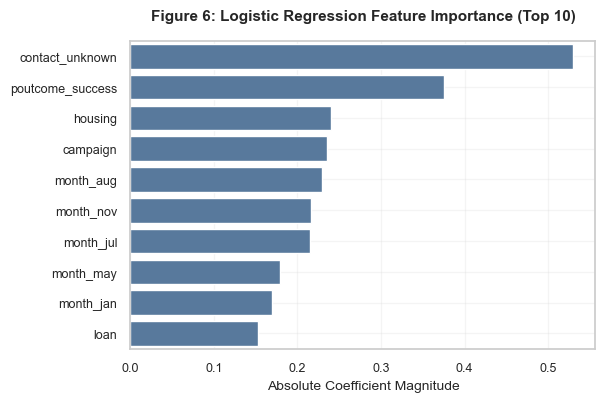

Feature,Coefficient
contact_unknown,-0.530217
poutcome_success,0.375985
housing,-0.239590
campaign,-0.235312
month_aug,-0.229112
month_nov,-0.216643
month_jul,-0.214380
month_may,-0.178654
month_jan,-0.168933
loan,-0.152756


In [20]:
# Logistic Regression Feature Importance
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': logit_model.coef_[0]
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values(
    by = 'Abs_Coefficient',
    ascending = False
)

coef_disp = coef_df.drop(columns = ['Abs_Coefficient']).round(6)

# Plot: Feature Importance
sns.set_theme(style = 'whitegrid')

plt.figure(figsize = (6, 4))

ax = sns.barplot(
    data = coef_df.head(10),
    x = 'Abs_Coefficient',
    y = 'Feature',
    color = '#4C78A8',
    edgecolor = 'white',
    linewidth = 1
)

ax.set_xlabel('Absolute Coefficient Magnitude', fontsize = 10)
ax.set_ylabel('')

ax.tick_params(axis = 'both', labelsize = 9)

ax.set_axisbelow(True)
ax.grid(True, alpha = 0.2)

plt.title(
    'Figure 6: Logistic Regression Feature Importance (Top 10)',
    fontsize = 11,
    fontweight = 'bold',
    pad = 15
)

plt.show()

display(HTML('<br><b>Table A1: Logistic Regression Feature Importance (Top 10)</b>'))
display(
    coef_disp.head(10)
        .style
        .hide(axis = 'index')
        .set_properties(subset = ['Feature'], **{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th.col_heading.level0.col0',
             'props': [('text-align', 'left')]}
        ])
)


- Logistic regression provides an interpretable, stable baseline capturing meaningful customer/marketing relationships


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Model Diagnostics & Dimensionality Considerations.
</span>

- Dimensionality reduction/regularization considered after the baseline fit
- Correlation analysis showed limited multicollinearity; training/test performance was similar (minimal overfitting)
- PCA and similar methods not pursued: model retains interpretability with stable performance


### Random Forest Model

- Ensemble of decision trees, each trained on a bootstrap sample with a random predictor subset per split
- Randomization reduces correlation among trees, improving stability and accuracy
- Final prediction: majority vote across all trees


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Hyperparameter Selection.
</span>

- Grid search, 5-fold cross-validation on training data
- Tuned: `n_estimators`, `max_features`, `max_depth`, `min_samples_leaf`
- Selected by average cross-validated AUC
- Optimal: 500 trees, `max_features = sqrt`, `max_depth = None`, `min_samples_leaf = 5`


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Model Performance.
</span>

- Training: accuracy 0.9065 (error 0.0935), AUC 0.9457: strong in-sample fit
- Test: accuracy 0.8959 (error 0.1041), AUC 0.7999: modest improvement over logistic regression
- Improved identification of subscriptions vs. logistic regression, with some remaining false negatives from class imbalance
- Train/test gap suggests good generalization despite added flexibility


In [21]:
# Random Forest Model
param_grid_rf = {
    'n_estimators': [200, 500],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5]
}

rf = RandomForestClassifier(random_state = 7, n_jobs = 6)

# Grid Search (7-Fold CV)
grid_rf = GridSearchCV(
    estimator = rf,
    param_grid = param_grid_rf,
    cv = 7,
    scoring = 'roc_auc',
    n_jobs = 6
)

grid_rf.fit(X_train, y_train)

rf_model = grid_rf.best_estimator_


In [22]:
# Training Performance
y_train_pred_rf = rf_model.predict(X_train)
y_train_prob_rf = rf_model.predict_proba(X_train)[:,1]

train_cm_rf = confusion_matrix(y_train, y_train_pred_rf)

train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
train_error_rf = 1 - train_accuracy_rf
train_auc_rf = roc_auc_score(y_train, y_train_prob_rf)

display(HTML(f"""
    <br><b>Training Performance</b><br>

    Accuracy:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_accuracy_rf:.4f}
    </span><br>

    Error:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_error_rf:.4f}
    </span><br>

    AUC:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_auc_rf:.4f}
    </span><br>
"""))

display_confusion_matrix(train_cm_rf, 'Confusion Matrix')


,Predicted 0,Predicted 1
Actual 0,27784,161
Actual 1,2797,905


In [23]:
# Selected Hyperparameters
display(HTML(f"""
    <br><b>Selected Hyperparameters</b><br>
    
    n_estimators: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid_rf.best_params_['n_estimators']}<br>
    </span>
        
    max_features: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid_rf.best_params_['max_features']}<br>
    </span>
        
    max_depth: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid_rf.best_params_['max_depth']}<br>
    </span>
        
    min_samples_leaf: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid_rf.best_params_['min_samples_leaf']}
    </span><br>
        
"""))


In [24]:
# Test Performance
y_test_pred_rf = rf_model.predict(X_test)
y_test_prob_rf = rf_model.predict_proba(X_test)[:,1]

test_cm_rf = confusion_matrix(y_test, y_test_pred_rf)

test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
test_error_rf = 1 - test_accuracy_rf
test_auc_rf = roc_auc_score(y_test, y_test_prob_rf)

display(HTML(f"""
    <br><b>Test Performance</b><br>

    Accuracy:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_accuracy_rf:.4f}
    </span><br>

    Error:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_error_rf:.4f}
    </span><br>

    AUC:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_auc_rf:.4f}
    </span><br>
"""))

display_confusion_matrix(test_cm_rf, 'Confusion Matrix')


,Predicted 0,Predicted 1
Actual 0,11850,127
Actual 1,1285,302


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Feature Importance.
</span>

- **Figure 7**: ten most important predictors
- Most influential: `poutcome_success`
- Also important: `age`, `balance` (demographic/financial), `day`, `pdays` (timing/recency)
- Campaign-related: `previous`, `campaign`, `contact_unknown`
- See **Appendix A** (Table A2) for detailed rankings


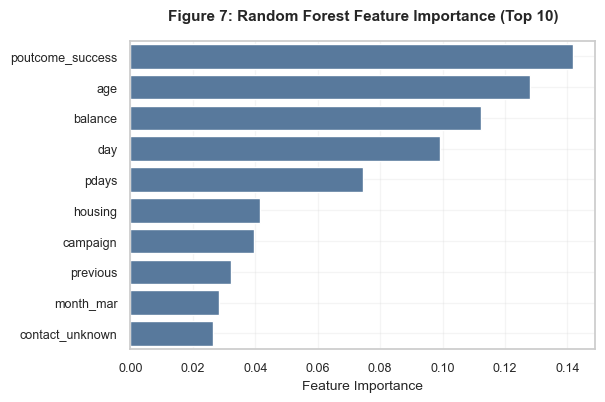

Feature,Importance
poutcome_success,0.141891
age,0.127929
balance,0.112303
day,0.099265
pdays,0.074667
housing,0.041402
campaign,0.039602
previous,0.032324
month_mar,0.028342
contact_unknown,0.026421


In [25]:
# Feature Importance
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by = 'Importance', ascending = False)

importance_df = importance_df.round(6)

# Plot: Feature Importance
sns.set_theme(style = 'whitegrid')

plt.figure(figsize = (6, 4))

ax = sns.barplot(
    data = importance_df.head(10),
    x = 'Importance',
    y = 'Feature',
    color = '#4C78A8',
    edgecolor = 'white',
    linewidth = 1
)

ax.set_xlabel('Feature Importance', fontsize = 10)
ax.set_ylabel('')

ax.tick_params(axis = 'both', labelsize = 9)

ax.set_axisbelow(True)
ax.grid(True, alpha = 0.2)

plt.title(
    'Figure 7: Random Forest Feature Importance (Top 10)',
    fontsize = 11,
    fontweight = 'bold',
    pad = 15
)

plt.show()

display(HTML('<br><b>Table A2: Random Forest Feature Importance (Top 10)</b>'))
display(
    importance_df.head(10)
        .style
        .hide(axis = 'index')
        .set_properties(subset = ['Feature'], **{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th.col_heading.level0.col0',
             'props': [('text-align', 'left')]}
        ])
)


- Random forest captures nonlinear relationships/interactions, modestly improving on logistic regression (higher AUC, similar accuracy)
- Next: evaluate a boosting-based ensemble for further gains


### Gradient Boosting Model

- Builds trees sequentially, each correcting the errors of the previous ones
- Harder-to-classify observations get more emphasis in later iterations
- Captures complex nonlinear relationships and interactions while progressively improving accuracy


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Hyperparameter Selection.
</span>

- Grid search, 5-fold cross-validation on training data
- Tuned: `n_estimators`, `learning_rate`, `max_depth`, `min_samples_leaf`
- Selected by average cross-validated AUC
- Optimal: 200 trees, `learning_rate = 0.1`, `max_depth = 4`, `min_samples_leaf = 1`


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Model Performance.
</span>

- Training: accuracy 0.9092 (error 0.0908), AUC 0.8359: strong in-sample fit
- Test: accuracy 0.8954 (error 0.1046), AUC 0.8058: highest test AUC among all models
- Improved identification of positive subscriptions vs. logistic regression; some false negatives remain from class imbalance


In [26]:
# Gradient Boosting Model
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_leaf': [1, 5]
}

gb = GradientBoostingClassifier(random_state = 7)

# Grid Search (7-Fold CV)
grid_gb = GridSearchCV(
    estimator = gb,
    param_grid = param_grid_gb,
    cv = 7,
    scoring = 'roc_auc',
    n_jobs = 6
)

grid_gb.fit(X_train, y_train)

gb_model = grid_gb.best_estimator_


In [27]:
# Training Performance
y_train_pred_gb = gb_model.predict(X_train)
y_train_prob_gb = gb_model.predict_proba(X_train)[:,1]

train_cm_gb = confusion_matrix(y_train, y_train_pred_gb)

train_accuracy_gb = accuracy_score(y_train, y_train_pred_gb)
train_error_gb = 1 - train_accuracy_gb
train_auc_gb = roc_auc_score(y_train, y_train_prob_gb)

display(HTML(f"""
    <br><b>Training Performance</b><br>

    Accuracy:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_accuracy_gb:.4f}
    </span><br>

    Error:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_error_gb:.4f}
    </span><br>

    AUC:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_auc_gb:.4f}
    </span><br>
"""))

display_confusion_matrix(train_cm_gb, 'Confusion Matrix')


,Predicted 0,Predicted 1
Actual 0,27636,309
Actual 1,2564,1138


In [28]:
# Selected Hyperparameters
display(HTML(f"""
    <br><b>Selected Hyperparameters</b><br>

    n_estimators: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid_gb.best_params_['n_estimators']}<br>
    </span>
    
    learning_rate: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid_gb.best_params_['learning_rate']}<br>
    </span>
    
    max_depth: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid_gb.best_params_['max_depth']}<br>
    </span>
    
    min_samples_leaf: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grid_gb.best_params_['min_samples_leaf']}
    </span>
"""))


In [29]:
# Test Performance
y_test_pred_gb = gb_model.predict(X_test)
y_test_prob_gb = gb_model.predict_proba(X_test)[:,1]

test_cm_gb = confusion_matrix(y_test, y_test_pred_gb)

test_accuracy_gb = accuracy_score(y_test, y_test_pred_gb)
test_error_gb = 1 - test_accuracy_gb
test_auc_gb = roc_auc_score(y_test, y_test_prob_gb)

display(HTML(f"""
    <br><b>Test Performance</b><br>

    Accuracy:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_accuracy_gb:.4f}
    </span><br>

    Error:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_error_gb:.4f}
    </span><br>

    AUC:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_auc_gb:.4f}
    </span><br>
"""))

display_confusion_matrix(test_cm_gb, 'Confusion Matrix')


,Predicted 0,Predicted 1
Actual 0,11748,229
Actual 1,1190,397


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Feature Importance.
</span>

- **Figure 8**: ten most important predictors
- Most influential: `poutcome_success`
- Also important: `age`, `balance`, `day`, `pdays`
- Also: `contact_unknown` and seasonal indicators (`month_mar`, `month_oct`, `month_jun`), plus `housing`
- See **Appendix A** (Table A2) for detailed rankings


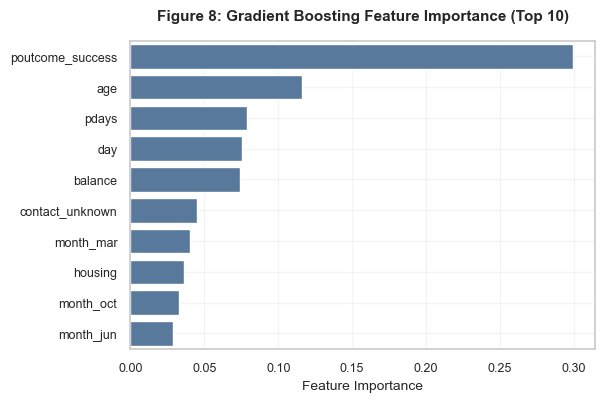

Feature,Importance
poutcome_success,0.299537
age,0.115926
pdays,0.079118
day,0.075253
balance,0.074262
contact_unknown,0.045069
month_mar,0.040290
housing,0.035988
month_oct,0.032789
month_jun,0.028708


In [30]:
# Feature Importance
importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_model.feature_importances_
}).sort_values(by = 'Importance', ascending = False)

importance_xgb = importance_xgb.round(6)

# Plot: Feature Importance
sns.set_theme(style = 'whitegrid')

plt.figure(figsize = (6, 4))

ax = sns.barplot(
    data = importance_xgb.head(10),
    x = 'Importance',
    y = 'Feature',
    color = '#4C78A8',
    edgecolor = 'white',
    linewidth = 1
)

ax.set_xlabel('Feature Importance', fontsize = 10)
ax.set_ylabel('')

ax.tick_params(axis = 'both', labelsize = 9)

ax.set_axisbelow(True)
ax.grid(True, alpha = 0.2)

plt.title(
    'Figure 8: Gradient Boosting Feature Importance (Top 10)',
    fontsize = 11,
    fontweight = 'bold',
    pad = 15
)

plt.show()

display(HTML('<br><b>Table A3: Gradient Boosting Feature Importance (Top 10)</b>'))
display(
    importance_xgb.head(10)
        .style
        .hide(axis = 'index')
        .set_properties(subset = ['Feature'], **{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th.col_heading.level0.col0',
             'props': [('text-align', 'left')]}
        ])
)


- Boosting achieves the strongest classification performance overall, by test AUC and competitive test error
- Captures complex patterns while maintaining stable out-of-sample performance


## Results

- Reports misclassification error for a single hold-out train/test split and Monte Carlo cross-validation
- Compares predictive accuracy, generalization, and stability across models
- Identifies the strongest-performing method while illustrating complexity/interpretability tradeoffs


### Model Performance Evaluation

- **Table 4** summarizes training/test error and AUC across all three classifiers
- Logistic regression: test error 0.1069, test AUC 0.7733: strong baseline
- Random forest: test error 0.1041, test AUC 0.7999: improves on logistic regression, but a much higher training AUC (0.9457) suggests some overfitting
- Gradient boosting: highest test AUC (0.8058), competitive test error (0.1046): strongest overall performance


In [31]:
# Logistic Regression Errors
train_error_logit = 1 - accuracy_score(y_train, y_train_pred)
test_error_logit = 1 - accuracy_score(y_test, y_test_pred)

# Random Forest Errors
train_error_rf = 1 - accuracy_score(y_train, y_train_pred_rf)
test_error_rf = 1 - accuracy_score(y_test, y_test_pred_rf)

# Gradient Boosting Errors
train_error_gb = 1 - accuracy_score(y_train, y_train_pred_gb)
test_error_gb = 1 - accuracy_score(y_test, y_test_pred_gb)

# Model Comparison Table
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Training Error': [
        train_error_logit,
        train_error_rf,
        train_error_gb
    ],
    'Test Error': [
        test_error_logit,
        test_error_rf,
        test_error_gb
    ],
    'Training AUC': [
        train_auc,
        train_auc_rf,
        train_auc_gb
    ],
    'Test AUC': [
        test_auc,
        test_auc_rf,
        test_auc_gb
    ]
})

model_results = model_results.round(4)

model_results = model_results.sort_values(
    by = 'Test Error',
    ascending = True
)

display(HTML('<br><b>Table 4: Training & Test Performance Comparison Across Models</b>'))

display(
    model_results.style
        .hide(axis = 'index')
        .set_properties(subset = ['Model'], **{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th.col_heading.level0.col0',
             'props': [('text-align', 'left')]}
        ])
)


Model,Training Error,Test Error,Training AUC,Test AUC
Random Forest,0.093500,0.104100,0.945700,0.799900
Gradient Boosting,0.090800,0.104600,0.835900,0.805800
Logistic Regression,0.108200,0.106900,0.765600,0.773300


- **Figure 9**: ROC curves on the test set
- Gradient boosting shows the strongest discrimination, followed by random forest, then logistic regression: consistent with **Table 4**'s AUC results
- Test misclassification error differs little across models, but ROC analysis favors boosting overall


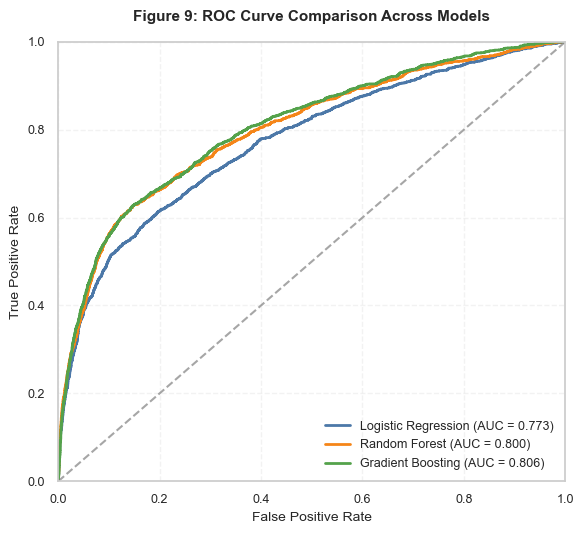

In [32]:
# Plot: ROC Curve
y_prob_logit = logit_model.predict_proba(X_test_scaled)[:,1]
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

fpr_logit, tpr_logit, _ = roc_curve(y_test, y_prob_logit)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.figure(figsize = (6, 5.5))

# Logistic Regression
plt.plot(
    fpr_logit, tpr_logit,
    linewidth = 2,
    color = '#4C78A8',
    label = f'Logistic Regression (AUC = {test_auc:.3f})'
)

# Random Forest
plt.plot(
    fpr_rf, tpr_rf,
    linewidth = 2,
    color = '#F58518',
    label = f'Random Forest (AUC = {test_auc_rf:.3f})'
)

# Gradient Boosting
plt.plot(
    fpr_gb, tpr_gb,
    linewidth = 2,
    color = '#54A24B',
    label = f'Gradient Boosting (AUC = {test_auc_gb:.3f})'
)

plt.plot(
    [0,1],[0,1],
    linestyle = '--',
    linewidth = 1.5,
    color = 'gray',
    alpha = 0.7
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xlabel('False Positive Rate', fontsize = 10)
plt.ylabel('True Positive Rate', fontsize = 10)

plt.xticks(fontsize = 9)
plt.yticks(fontsize = 9)

# Plot: ROC Comparison Curves
plt.title(
    'Figure 9: ROC Curve Comparison Across Models',
    fontsize = 11,
    fontweight = 'bold',
    pad = 15
)

plt.legend(
    frameon = False,
    fontsize = 9,
    loc = 'lower right'
)

plt.grid(
    alpha = 0.25,
    linestyle = '--'
)

plt.tight_layout()
plt.show()


### Feature Importance

- Compares feature importance across all three models (**Figure 10**, heatmap); values normalized within each model since metrics differ (coefficient magnitude vs. impurity-based measures)
- `poutcome_success` is important across all models, especially random forest and gradient boosting
- Tree-based models emphasize continuous variables: `age`, `balance`, `day`, `pdays`
- Logistic regression emphasizes campaign/contact indicators: `contact_unknown`, seasonal `month` variables (`month_mar`, `month_aug`, `month_jul`, `month_nov`), and `housing`


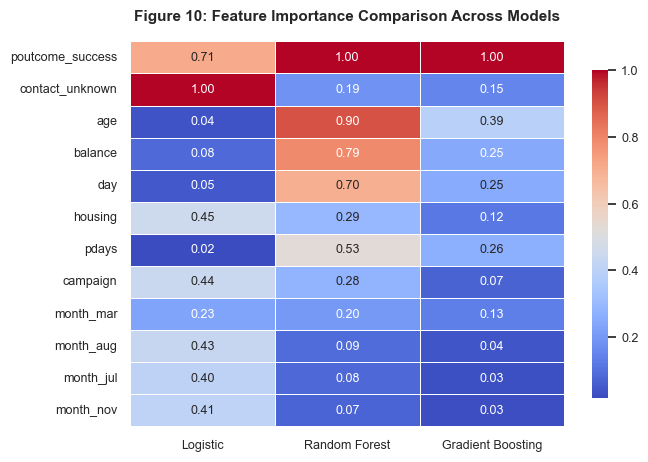

In [33]:
# Feature Importance
logit_imp = pd.Series(np.abs(logit_model.coef_[0]), index = X_train.columns)
rf_imp = pd.Series(rf_model.feature_importances_, index = X_train.columns)
gb_imp = pd.Series(gb_model.feature_importances_, index = X_train.columns)

importance_compare = pd.DataFrame({
    'Logistic': logit_imp,
    'Random Forest': rf_imp,
    'Gradient Boosting': gb_imp
})

importance_compare = importance_compare / importance_compare.max()

top_features = importance_compare.mean(axis = 1)\
    .sort_values(ascending = False)\
    .head(12)\
    .index

importance_compare = importance_compare.loc[top_features]

# Heatmap: Feature Importance
sns.set_theme(style = 'whitegrid')

plt.figure(figsize = (7, 5))

ax = sns.heatmap(
    importance_compare,
    cmap = 'coolwarm',
    annot = True,
    fmt = '.2f',
    linewidths = 0.5,
    annot_kws = {'size': 9},
    cbar_kws = {'shrink': 0.85}
)

ax.collections[0].colorbar.ax.tick_params(labelsize = 9)

ax.set_ylabel('', fontsize = 9)
ax.set_xlabel('', fontsize = 9)
ax.tick_params(axis = 'both', labelsize = 9)

plt.title(
    'Figure 10: Feature Importance Comparison Across Models',
    fontsize = 11,
    fontweight = 'bold',
    pad = 15
)

plt.show()


### Monte Carlo Cross-Validation

- Repeated random train/test splits used for more stable performance estimates than a single hold-out split
- Each iteration: random partition, fit on training data, evaluate on the corresponding test data


<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Cross-Validation Performance.
</span>

- **Table 5**: results across 100 replications for all three models
- Random forest: lowest mean test error (0.1054)
- Gradient boosting: highest mean test AUC (0.7990)
- Both ensembles outperform logistic regression (mean test error 0.1089, mean test AUC 0.7626)
- Suggests tree-based ensembles capture nonlinear relationships/interactions more effectively than logistic regression


In [34]:
# Monte Carlo Cross-Validation
rng = np.random.default_rng(7)
random_seeds = rng.integers(0, 10_000, size = 100)

mccv_results = {
    'Logistic Regression': {'train_error': [], 'test_error': [], 'train_auc': [], 'test_auc': []},
    'Random Forest': {'train_error': [], 'test_error': [], 'train_auc': [], 'test_auc': []},
    'Boosting': {'train_error': [], 'test_error': [], 'train_auc': [], 'test_auc': []}
}

numeric_cols = X_raw.select_dtypes(include = ['int64','float64']).columns
categorical_cols = X_raw.select_dtypes(include = ['object']).columns

for seed in random_seeds:

    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_raw, y_raw,
        test_size = 0.30,
        stratify = y_raw,
        random_state = seed
    )

    # Preprocessing
    preprocessor = ColumnTransformer(
        transformers = [
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(drop = 'first', handle_unknown = 'ignore'), categorical_cols)
        ]
    )

    X_train_proc = preprocessor.fit_transform(X_train)
    X_test_proc = preprocessor.transform(X_test)

    # Logistic Regression w/Fixed Hyperparameters
    logit = LogisticRegression(
        C = 0.01,
        max_iter = 5000,
        random_state = 7
    )

    logit.fit(X_train_proc, y_train)

    y_train_pred = logit.predict(X_train_proc)
    y_test_pred = logit.predict(X_test_proc)

    y_train_prob = logit.predict_proba(X_train_proc)[:,1]
    y_test_prob = logit.predict_proba(X_test_proc)[:,1]

    mccv_results['Logistic Regression']['train_error'].append(1 - accuracy_score(y_train, y_train_pred))
    mccv_results['Logistic Regression']['test_error'].append(1 - accuracy_score(y_test, y_test_pred))
    mccv_results['Logistic Regression']['train_auc'].append(roc_auc_score(y_train, y_train_prob))
    mccv_results['Logistic Regression']['test_auc'].append(roc_auc_score(y_test, y_test_prob))

    # Random Forest w/Fixed Hyperparameters
    rf = RandomForestClassifier(
        n_estimators = 200,
        max_features = 'sqrt',
        max_depth = 20,
        min_samples_leaf = 5,
        random_state = 7,
        n_jobs = 6
    )

    rf.fit(X_train_proc, y_train)

    y_train_pred = rf.predict(X_train_proc)
    y_test_pred = rf.predict(X_test_proc)

    y_train_prob = rf.predict_proba(X_train_proc)[:,1]
    y_test_prob = rf.predict_proba(X_test_proc)[:,1]

    mccv_results['Random Forest']['train_error'].append(1 - accuracy_score(y_train, y_train_pred))
    mccv_results['Random Forest']['test_error'].append(1 - accuracy_score(y_test, y_test_pred))
    mccv_results['Random Forest']['train_auc'].append(roc_auc_score(y_train, y_train_prob))
    mccv_results['Random Forest']['test_auc'].append(roc_auc_score(y_test, y_test_prob))

    # Gradient Boosting w/Fixed Hyperparameters
    gb = GradientBoostingClassifier(
        n_estimators = 200,
        learning_rate = 0.1,
        max_depth = 4,
        min_samples_leaf = 5,
        random_state = 7
    )

    gb.fit(X_train_proc, y_train)

    y_train_pred = gb.predict(X_train_proc)
    y_test_pred = gb.predict(X_test_proc)

    y_train_prob = gb.predict_proba(X_train_proc)[:,1]
    y_test_prob = gb.predict_proba(X_test_proc)[:,1]

    mccv_results['Boosting']['train_error'].append(1 - accuracy_score(y_train, y_train_pred))
    mccv_results['Boosting']['test_error'].append(1 - accuracy_score(y_test, y_test_pred))
    mccv_results['Boosting']['train_auc'].append(roc_auc_score(y_train, y_train_prob))
    mccv_results['Boosting']['test_auc'].append(roc_auc_score(y_test, y_test_prob))

# Summary Table
mccv_summary = pd.DataFrame({
    model: {
        'Mean Training Error': np.mean(vals['train_error']),
        'Training Error Std. Dev.': np.std(vals['train_error'], ddof = 1),
        'Mean Test Error': np.mean(vals['test_error']),
        'Test Error Std. Dev.': np.std(vals['test_error'], ddof = 1),
        'Mean Training AUC': np.mean(vals['train_auc']),
        'Training AUC Std. Dev.': np.std(vals['train_auc'], ddof = 1),
        'Mean Test AUC': np.mean(vals['test_auc']),
        'Test AUC Std. Dev.': np.std(vals['test_auc'], ddof = 1)
    }
    for model, vals in mccv_results.items()
}).T

mccv_summary = mccv_summary.sort_values('Mean Test Error').reset_index()
mccv_summary = mccv_summary.rename(columns = {'index':'Model'})
mccv_summary = mccv_summary.round(4)


In [35]:
# Monte Carlo Cross-Validation Summary
mccv_display = mccv_summary[
    [
        'Model',
        'Mean Test Error',
        'Test Error Std. Dev.',
        'Mean Test AUC',
        'Test AUC Std. Dev.'
    ]
]
    
display(HTML('<br><b>Table 5: Monte Carlo Cross-Validation Summary of Model Performance</b>'))
display(
    mccv_display
        .style
        .hide(axis = 'index')
        .set_properties(subset = ['Model'], **{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th.col_heading.level0.col0',
             'props': [('text-align', 'left')]}
        ])
)


Model,Mean Test Error,Test Error Std. Dev.,Mean Test AUC,Test AUC Std. Dev.
Random Forest,0.105400,0.001100,0.795900,0.005600
Boosting,0.106400,0.001500,0.799000,0.005900
Logistic Regression,0.108900,0.000800,0.762600,0.005800


- Ensemble methods show modest but consistent improvements over logistic regression
- Higher AUC for tree-based models indicates stronger discrimination across thresholds
- Small standard deviations in test error/AUC indicate stable performance across replications
- Confirms the hold-out pattern: random forest lowest average error, gradient boosting highest average AUC<span style="color: darkred; font-weight: bold;"><sup>4</sup></span>

---

<div style="margin-left:20px; text-indent:-10px;">
<span style="color: darkred; font-weight: bold;"><sup>4</sup></span> 
    Statistical significance testing was not conducted for the Monte Carlo cross-validation results because the repeated train-test splits are generated from the same dataset and therefore do not produce fully independent performance estimates. As a result, the relatively small differences in model performance should be viewed as general comparisons rather than definitive proof that one model statistically outperforms another.
</div>


## Conclusions & Model Selection

- Evaluated logistic regression, random forest, and gradient boosting for predicting client subscription, via a hold-out split and Monte Carlo cross-validation (100 replications)

<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Hold-Out Evaluation Results.
</span>

- Gradient boosting: highest test AUC (0.8058), competitive test error (0.1046)
- Random forest: lowest test error (0.1041), slightly lower AUC (0.7999)
- Logistic regression: test error 0.1069, test AUC 0.7733: solid but weaker baseline
- ROC comparison confirms boosting gives the strongest overall discrimination

<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Monte Carlo Cross-Validation Results.
</span>

- Random forest: lowest mean test error (0.1054)
- Gradient boosting: highest mean test AUC (0.7990)
- Both ensembles consistently outperform logistic regression on accuracy and discrimination

<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Feature Importance Comparison.
</span>

- `poutcome_success` consistently among the most important predictors across models
- Tree-based models emphasize continuous variables (`balance`, `age`, `day`)
- Logistic regression emphasizes campaign-related categorical variables (`contact_unknown`, `housing`, `month` indicators)

<span style="color:#1f4ed8; font-style:italic; font-weight:bold;">
Final Model Selection.
</span>

- <b><u>Gradient boosting selected as the preferred model</u></b>
- Random forest has the lowest average error, but boosting consistently has the highest AUC: stronger discrimination
- Error differences among ensembles are small, so boosting's AUC advantage is meaningful
- Boosting also offers flexibility for nonlinear relationships and interactions
